# Validating `reflectivity()` against Graebner's exact VTI reflection coefficient

This notebook cross-checks the Rüger (1998) symmetry-plane PP reflectivity in [`layered_media.reflectivity`](../src/layered_media.py) against the **exact** VTI plane-wave PP reflection coefficient of Graebner (1992) / Daley & Hron (1979).

The exact coefficient is obtained from first principles by solving the Christoffel equation for the qP/qSV vertical slownesses and the 4×4 P-SV boundary-value problem (continuity of displacement $u_x, u_z$ and stresses $\sigma_{zz}, \sigma_{xz}$). It shares **no code or derivation path** with the linearised Rüger approximation, so agreement is a genuine independent test.

For an interface between two VTI media the orthorhombic symmetry-plane reflectivities $R_{xz}$ and $R_{yz}$ both reduce to the VTI PP response, so they can be compared directly with the exact solution. Because the module is a **weak-contrast / weak-anisotropy linearisation**, it should converge to the exact result as contrast and anisotropy decrease, and deviate (smoothly, by design) for stronger contrast and larger angles — exactly the behaviour Rüger documents in his Fig. 2.

The exact solver and helpers are imported from [`tests/test_reflectivity_vs_graebner.py`](../tests/test_reflectivity_vs_graebner.py) to keep a single source of truth.

**References**
- Graebner, M., 1992, *Plane-wave reflection and transmission coefficients for a transversely isotropic solid*: Geophysics, 57, 1512–1519.
- Rüger, A., 1998, *Variation of P-wave reflectivity with offset and azimuth in anisotropic media*: Geophysics, 63, 935–947.

In [1]:
import os
import sys

import numpy as np
import matplotlib.pyplot as plt

# Make src/ and tests/ importable from the notebooks/ folder
sys.path.insert(0, os.path.join('..', 'src'))
sys.path.insert(0, os.path.join('..', 'tests'))

# Exact VTI solver, VTI tensor builder, angle sweep, and the test cases
from test_reflectivity_vs_graebner import compare, CASES

## Run the comparison

`compare()` builds VTI stiffness tensors for each layer, sweeps the incidence phase angle, evaluates the exact PP coefficient and the module's $R_{xz}$/$R_{yz}$ at the same angles, and returns the per-angle values plus summary diagnostics.

In [2]:
results = {label: compare(up, low) for label, (up, low) in CASES.items()}

for label, res in results.items():
    print(f'=== {label} ===')
    print(f"  normal incidence : exact={res['exact'][0]:+.6f}  "
          f"impedance={res['impedance_R0']:+.6f}  module={res['Rxz'][0]:+.6f}")
    print(f"  max|Rxz - Ryz|   : {res['xz_yz_diff']:.2e}  (must be ~0 for VTI)")
    print(f"  max|module-exact|: {res['max_abs_diff']:.5f}  (0-35 deg)\n")

=== isotropic, weak contrast ===
  normal incidence : exact=+0.046197  impedance=+0.046197  module=+0.046197
  max|Rxz - Ryz|   : 0.00e+00  (must be ~0 for VTI)
  max|module-exact|: 0.00054  (0-35 deg)

=== weak VTI, weak contrast ===
  normal incidence : exact=+0.050881  impedance=+0.050881  module=+0.050881
  max|Rxz - Ryz|   : 6.94e-18  (must be ~0 for VTI)
  max|module-exact|: 0.00356  (0-35 deg)

=== moderate VTI, moderate contrast ===
  normal incidence : exact=+0.132075  impedance=+0.132075  module=+0.132075
  max|Rxz - Ryz|   : 1.39e-17  (must be ~0 for VTI)
  max|module-exact|: 0.03569  (0-35 deg)



## Visual comparison

Solid black: exact (Graebner 1992). Dashed red: module (Rüger 1998). The curves track closely where the linearisation is valid and separate at large angles as anisotropy/contrast grow.

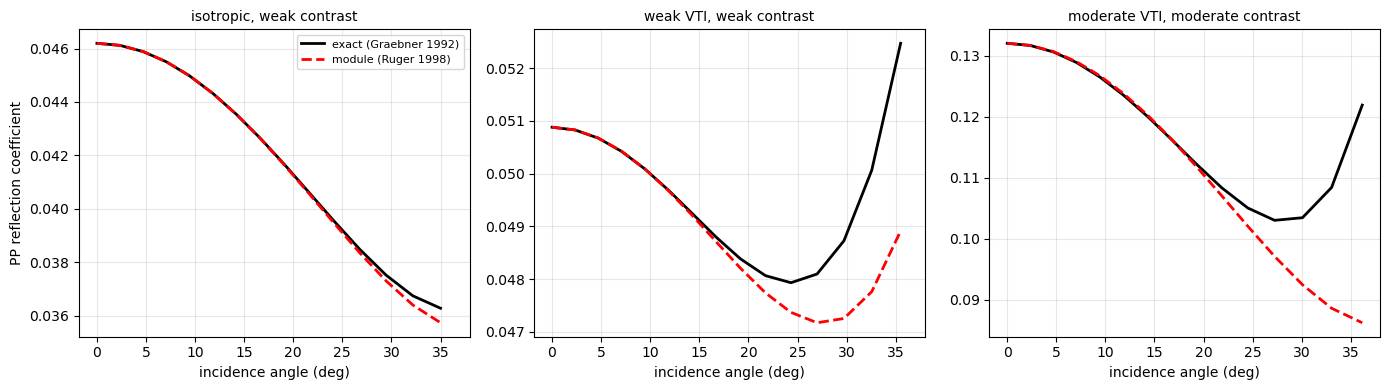

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharex=True)
for ax, (label, res) in zip(axes, results.items()):
    ax.plot(res['thetas_deg'], res['exact'], 'k-', lw=2, label='exact (Graebner 1992)')
    ax.plot(res['thetas_deg'], res['Rxz'], 'r--', lw=2, label='module (Ruger 1998)')
    ax.set_title(label, fontsize=10)
    ax.set_xlabel('incidence angle (deg)')
    ax.grid(alpha=0.3)
axes[0].set_ylabel('PP reflection coefficient')
axes[0].legend(fontsize=8, loc='best')
fig.tight_layout()
plt.show()

## Assertions

- The exact solver reproduces the acoustic-impedance reflection $(Z_2-Z_1)/(Z_2+Z_1)$ at normal incidence (a convention-independent anchor), and so does the module's intercept.
- $R_{xz} = R_{yz}$ to machine precision for VTI input.
- The module matches the exact solution tightly for the weak cases, and the discrepancy **grows** with contrast/anisotropy (linearisation error, not a bug).

In [4]:
ok = True

def check(name, condition):
    global ok
    ok = ok and bool(condition)
    print(f"[{'PASS' if condition else 'FAIL'}] {name}")

for label, res in results.items():
    check(f'{label}: exact R0 == impedance',
          np.isclose(res['exact'][0], res['impedance_R0'], atol=1e-9))
    check(f'{label}: module R0 == impedance',
          np.isclose(res['Rxz'][0], res['impedance_R0'], atol=1e-9))
    check(f'{label}: Rxz == Ryz (VTI)', res['xz_yz_diff'] < 1e-12)

check('isotropic weak: module ~ exact (<1e-3)',
      results['isotropic, weak contrast']['max_abs_diff'] < 1e-3)
check('weak VTI: module ~ exact (<5e-3)',
      results['weak VTI, weak contrast']['max_abs_diff'] < 5e-3)
check('error grows with contrast/anisotropy',
      results['isotropic, weak contrast']['max_abs_diff']
      < results['weak VTI, weak contrast']['max_abs_diff']
      < results['moderate VTI, moderate contrast']['max_abs_diff'])

print('\nALL CHECKS PASSED' if ok else '\nSOME CHECKS FAILED')

[PASS] isotropic, weak contrast: exact R0 == impedance
[PASS] isotropic, weak contrast: module R0 == impedance
[PASS] isotropic, weak contrast: Rxz == Ryz (VTI)
[PASS] weak VTI, weak contrast: exact R0 == impedance
[PASS] weak VTI, weak contrast: module R0 == impedance
[PASS] weak VTI, weak contrast: Rxz == Ryz (VTI)
[PASS] moderate VTI, moderate contrast: exact R0 == impedance
[PASS] moderate VTI, moderate contrast: module R0 == impedance
[PASS] moderate VTI, moderate contrast: Rxz == Ryz (VTI)
[PASS] isotropic weak: module ~ exact (<1e-3)
[PASS] weak VTI: module ~ exact (<5e-3)
[PASS] error grows with contrast/anisotropy

ALL CHECKS PASSED
